# Titanic Dataset — Exploratory Data Analysis (EDA)

**Objective:** Understand the Titanic dataset using summary statistics and visualizations (Pandas, Matplotlib, Seaborn).

**Dataset:** 891 passengers, 12 columns — `PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`.


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

df = pd.read_csv('Titanic-Dataset.csv')
print(df.shape)
df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe()  # numeric summary statistics

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.describe(include='object')  # categorical summary statistics

/tmp/ipykernel_557/3955700804.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')  # categorical summary statistics


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 3. Missing Values

`Cabin` is missing ~77% of the time, `Age` ~20%, and `Embarked` only 2 rows. These missingness levels will drive how we handle each column later (drop, flag, or impute).

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


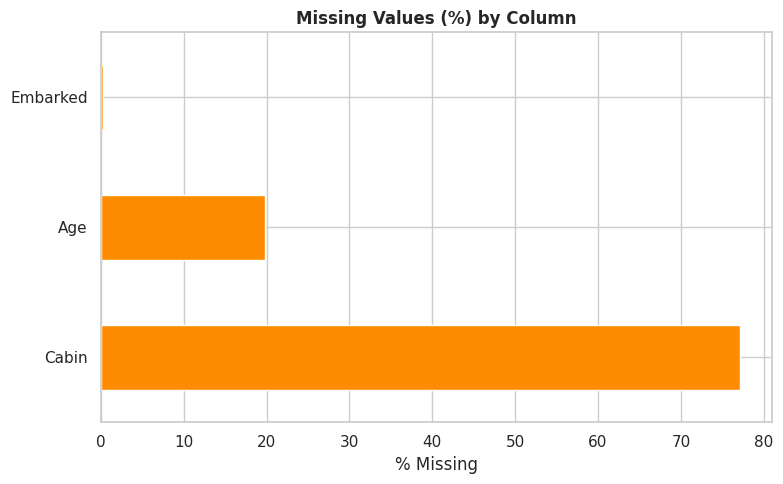

In [6]:
plt.figure(figsize=(8,5))
miss_pct = df.isnull().mean().sort_values(ascending=False) * 100
miss_pct = miss_pct[miss_pct > 0]
miss_pct.plot(kind='barh', color='darkorange')
plt.title('Missing Values (%) by Column', fontweight='bold')
plt.xlabel('% Missing')
plt.tight_layout()
plt.show()


## 4. Survival Rates by Key Groups

In [7]:
print("Overall survival rate:")
print(df['Survived'].value_counts(normalize=True).round(3))

print("\nBy Sex:")
print(df.groupby('Sex')['Survived'].mean().round(3))

print("\nBy Pclass:")
print(df.groupby('Pclass')['Survived'].mean().round(3))

print("\nBy Embarked:")
print(df.groupby('Embarked')['Survived'].mean().round(3))


Overall survival rate:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

By Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

By Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

By Embarked:
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64


## 5. Distributions of Numeric Features (Histograms)

`Fare` is heavily right-skewed; `Age` is roughly normal; `SibSp`/`Parch` are sparse (most passengers traveled alone).

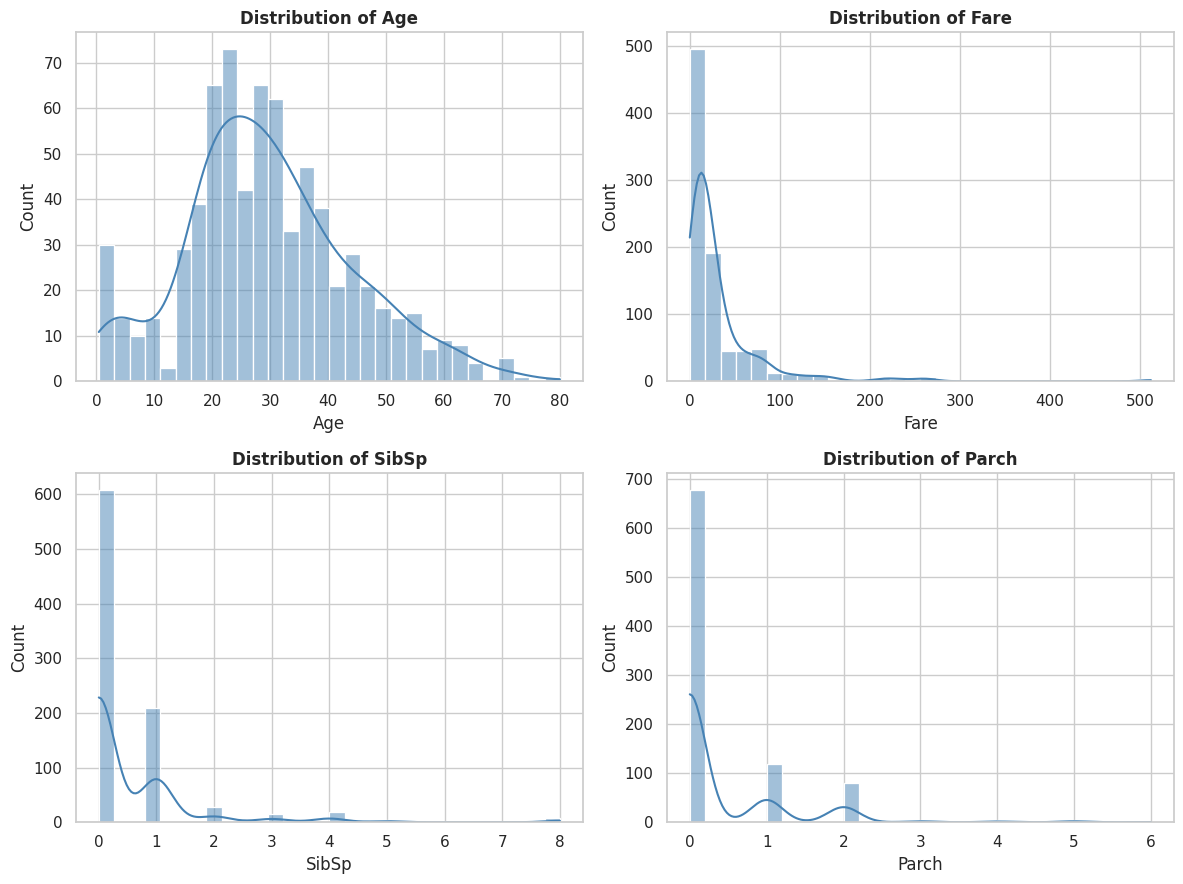

In [8]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
df[['Age','Fare','SibSp','Parch']].skew().round(3)  # skewness

Age      0.389
Fare     4.787
SibSp    3.695
Parch    2.749
dtype: float64

## 6. Boxplots (Outlier Detection)

`Fare` shows substantial high-end outliers (luxury tickets). `Age` has a handful of outliers at both extremes but is otherwise well-behaved.

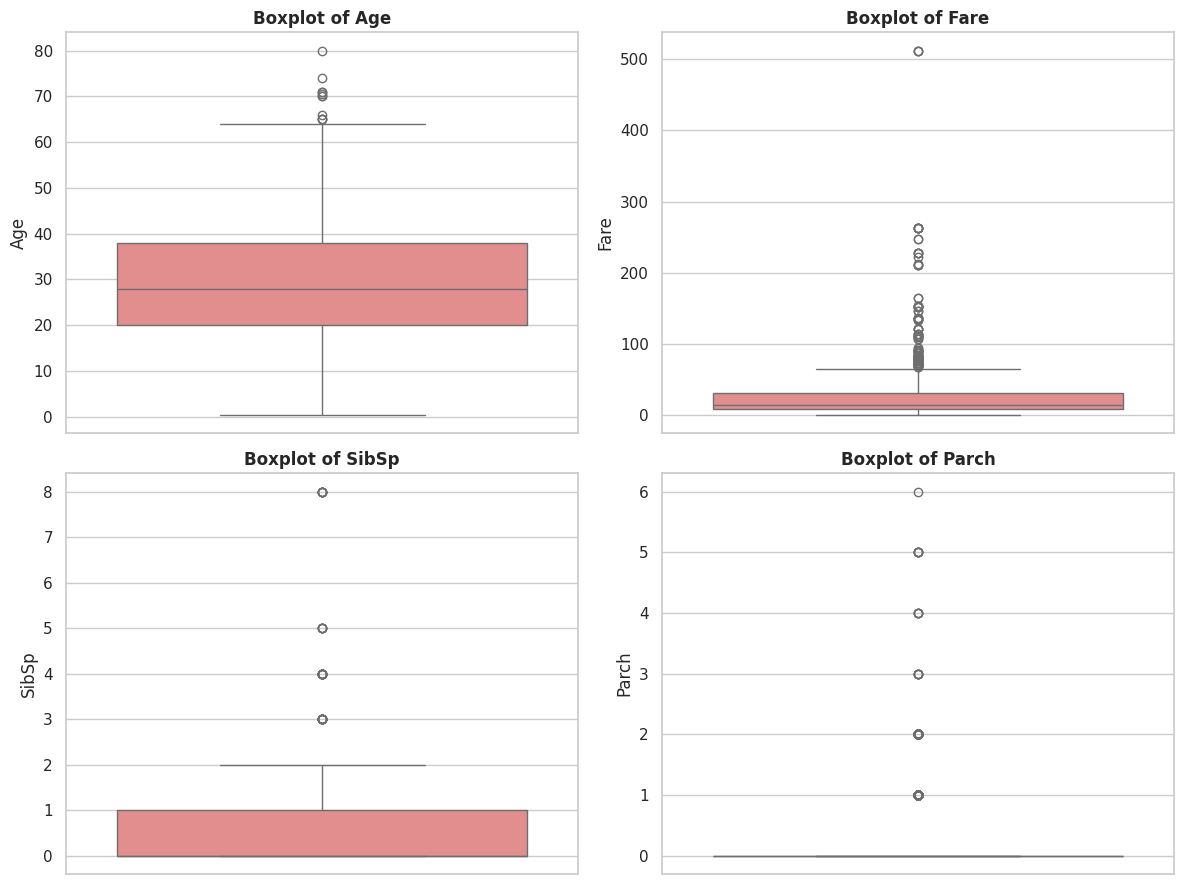

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Age & Fare by Survival

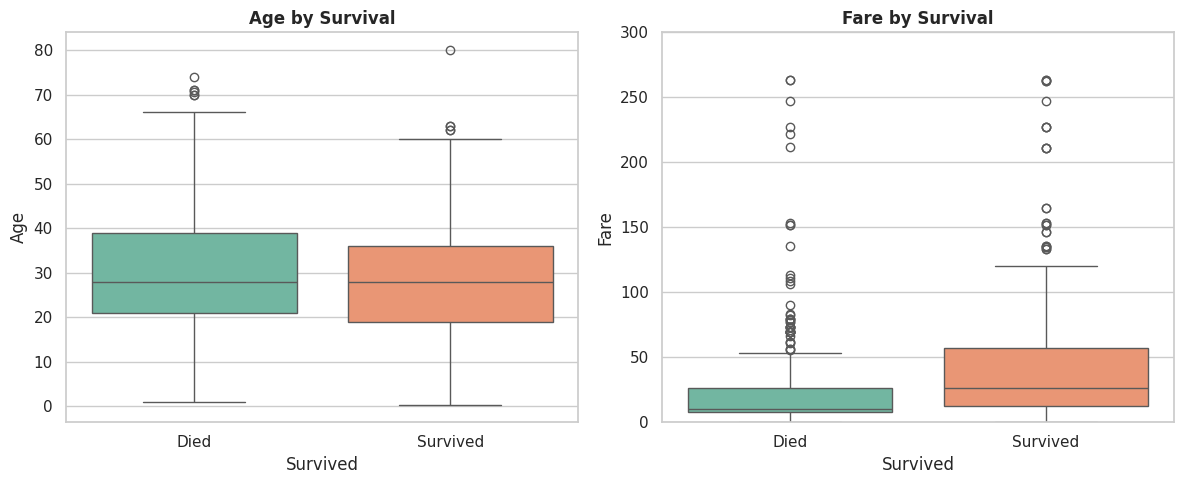

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[0], hue='Survived', palette='Set2', legend=False)
axes[0].set_title('Age by Survival', fontweight='bold')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Died','Survived'])

sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1], hue='Survived', palette='Set2', legend=False)
axes[1].set_title('Fare by Survival', fontweight='bold')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Died','Survived'])
axes[1].set_ylim(0, 300)
plt.tight_layout()
plt.show()


**Inference:** Survivors paid noticeably higher fares on average (a proxy for class/cabin location). Age differences between survivors and non-survivors are subtle — age alone is a weak linear predictor.

## 7. Age Distribution by Survival (KDE)

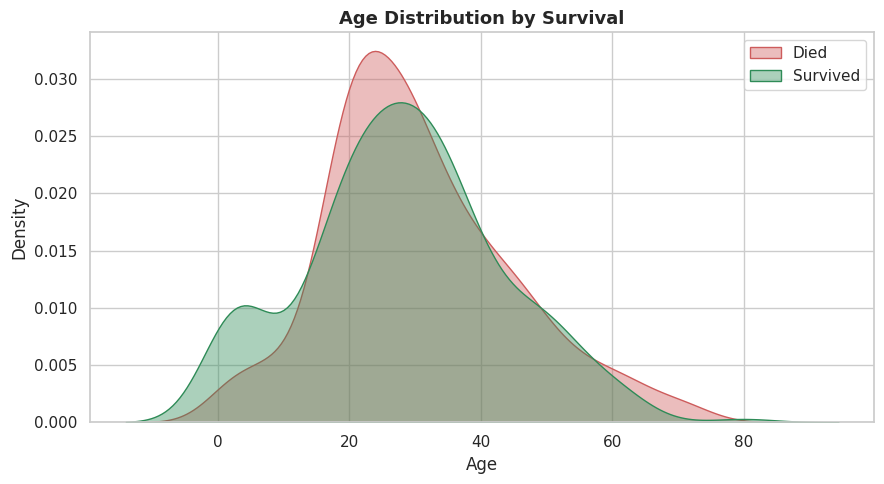

In [12]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df[df['Survived']==0], x='Age', fill=True, color='indianred', label='Died', alpha=0.4)
sns.kdeplot(data=df[df['Survived']==1], x='Age', fill=True, color='seagreen', label='Survived', alpha=0.4)
plt.title('Age Distribution by Survival', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


**Inference:** There's a visible survival density spike for young children (~0–10), consistent with "women and children first." Survival dips for young adult males (20–40).

## 8. Correlation Matrix

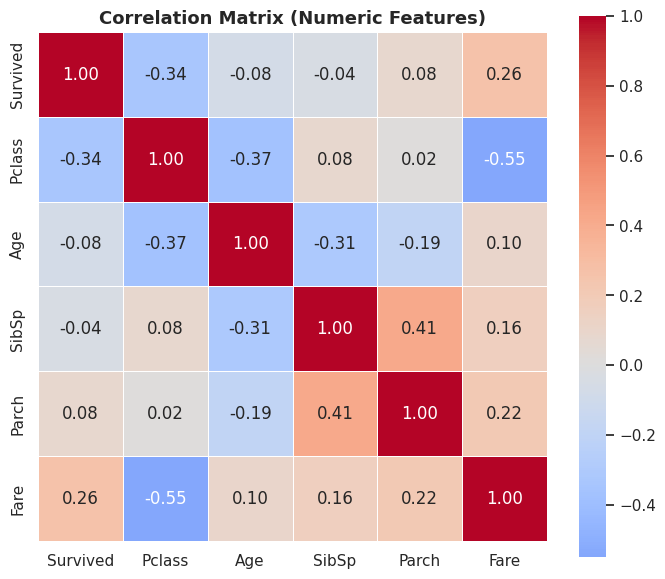

In [13]:
plt.figure(figsize=(7, 6))
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


**Inference:** `Pclass` (-0.34) and `Fare` (+0.26) correlate with `Survived` more strongly than `Age` (-0.08). `Pclass` and `Fare` are themselves strongly linked (-0.55) — two views of the same socio-economic signal. `SibSp`/`Parch` correlate (+0.41), hinting a combined `FamilySize` feature could help.

## 9. Pairplot of Key Numeric Features

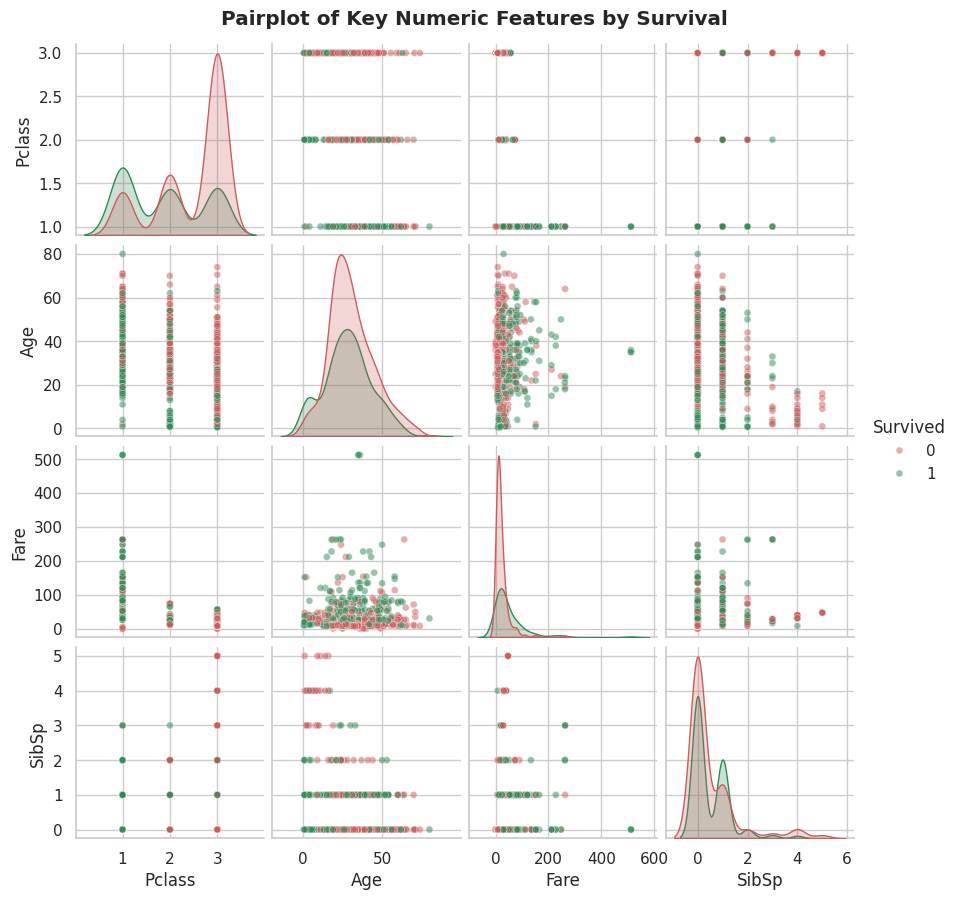

In [14]:
pp_df = df[['Survived','Pclass','Age','Fare','SibSp']].dropna()
g = sns.pairplot(pp_df, hue='Survived', palette={0:'indianred', 1:'seagreen'},
                  plot_kws={'alpha':0.5, 's':25}, diag_kind='kde', height=2.2)
g.fig.suptitle('Pairplot of Key Numeric Features by Survival', y=1.02, fontweight='bold')
plt.show()


**Inference:** `Fare` separates survivors from non-survivors better than `Age` or `SibSp` on the diagonal KDEs. No single numeric feature cleanly separates the classes — survival is likely driven by feature *interactions* (Sex + Pclass + Age together).

## 10. Categorical Features vs. Survival

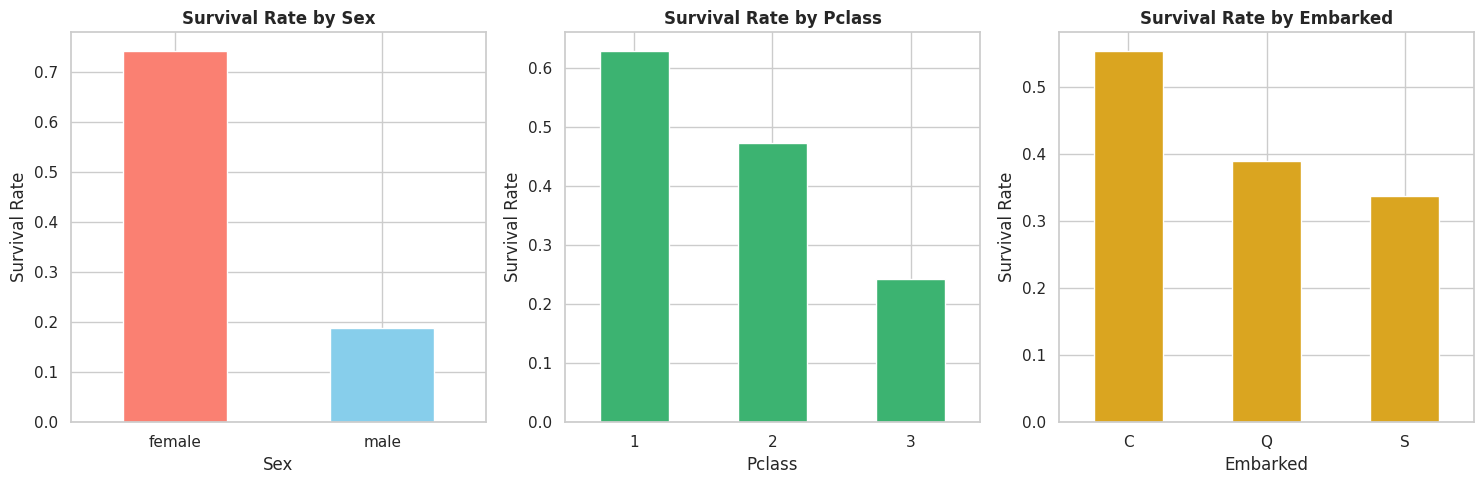

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sex_surv = df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['salmon','skyblue'])
axes[0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0].set_ylabel('Survival Rate'); axes[0].set_xticklabels(sex_surv.index, rotation=0)

pclass_surv = df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Survival Rate by Pclass', fontweight='bold')
axes[1].set_ylabel('Survival Rate'); axes[1].set_xticklabels(pclass_surv.index, rotation=0)

emb_surv = df.groupby('Embarked')['Survived'].mean()
emb_surv.plot(kind='bar', ax=axes[2], color='goldenrod')
axes[2].set_title('Survival Rate by Embarked', fontweight='bold')
axes[2].set_ylabel('Survival Rate'); axes[2].set_xticklabels(emb_surv.index, rotation=0)

plt.tight_layout()
plt.show()


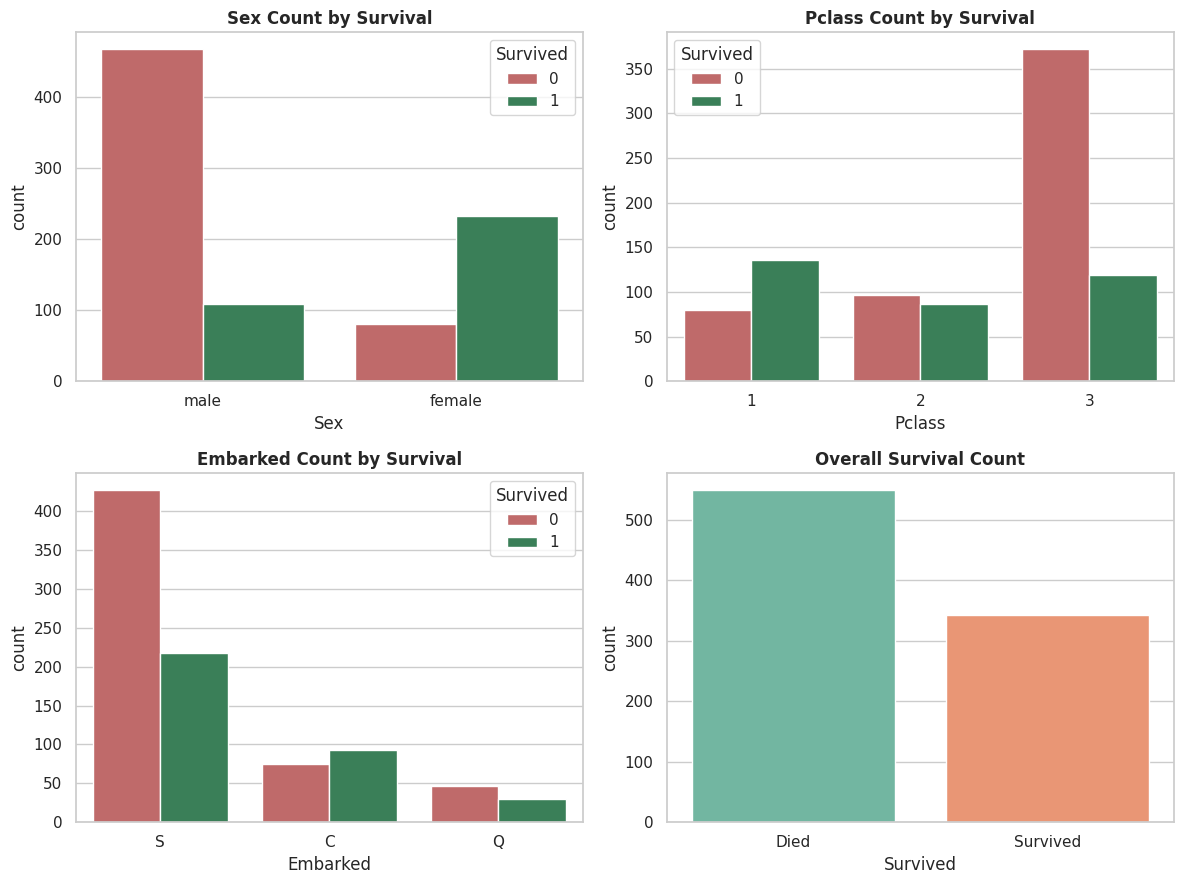

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,0], palette={0:'indianred',1:'seagreen'})
axes[0,0].set_title('Sex Count by Survival', fontweight='bold')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0,1], palette={0:'indianred',1:'seagreen'})
axes[0,1].set_title('Pclass Count by Survival', fontweight='bold')

sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1,0], palette={0:'indianred',1:'seagreen'})
axes[1,0].set_title('Embarked Count by Survival', fontweight='bold')

sns.countplot(data=df, x='Survived', ax=axes[1,1], hue='Survived', palette='Set2', legend=False)
axes[1,1].set_title('Overall Survival Count', fontweight='bold')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(['Died','Survived'])

plt.tight_layout()
plt.show()


**Inference:**
- **Sex is the single strongest predictor** — women survived at ~74% vs. ~19% for men.
- **Pclass shows a clean monotonic trend**: 63% (1st) → 47% (2nd) → 24% (3rd).
- **Embarked** differences (C 55% > Q 39% > S 34%) are likely a **confound** of class mix at each port rather than a direct causal effect.


## 11. Key Takeaways

1. **Sex and Pclass dominate survival** — far more than any single numeric feature's correlation coefficient suggests.
2. **Fare is right-skewed with real outliers** (luxury tickets up to £512); consider a log-transform before modeling.
3. **Cabin missingness (77%) is not random** — concentrated in 3rd class. A `Cabin Known` binary flag may itself be predictive.
4. **Age missingness (~20%)** should be imputed by group (e.g., by title extracted from `Name`) rather than with a single global value.
5. **Engineering `FamilySize = SibSp + Parch + 1`** is a reasonable next step given the +0.41 correlation between the two.
